# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.



In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

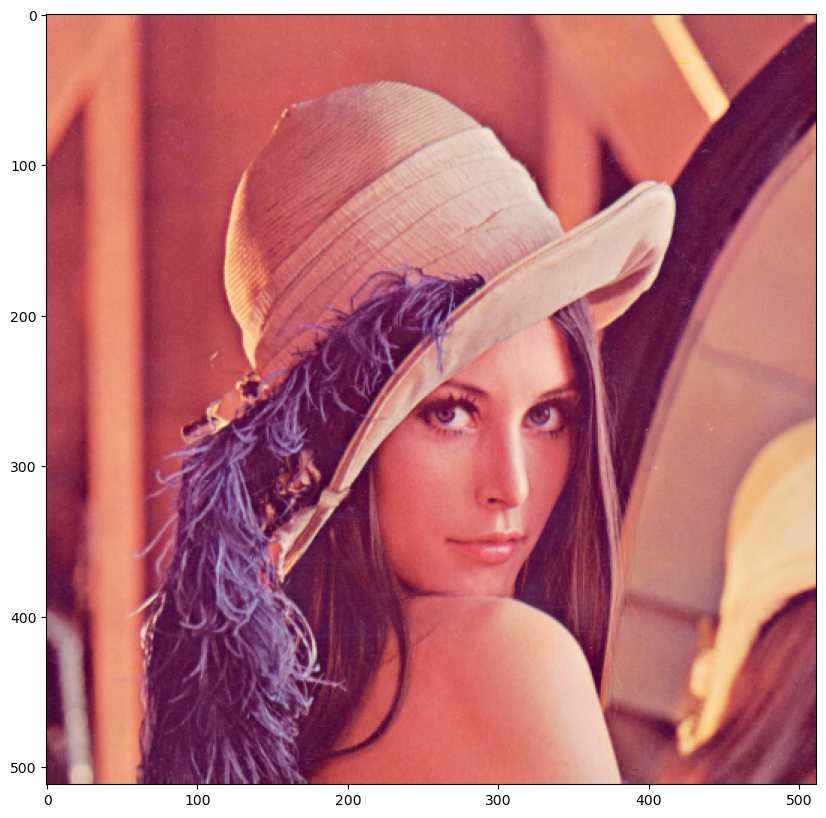

In [2]:
img = cv2.imread("face.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap='gray')

### Step 2

Load the dlib face predictor.

In [3]:
import dlib

detector = dlib.get_frontal_face_detector()

### Step 3

Run the predictor on your image.

In [4]:
faces = detector(img)

print(f"Faces: {len(faces)}")

Faces: 1


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

(<Axes: >, <matplotlib.image.AxesImage at 0x2ae97cb6780>)

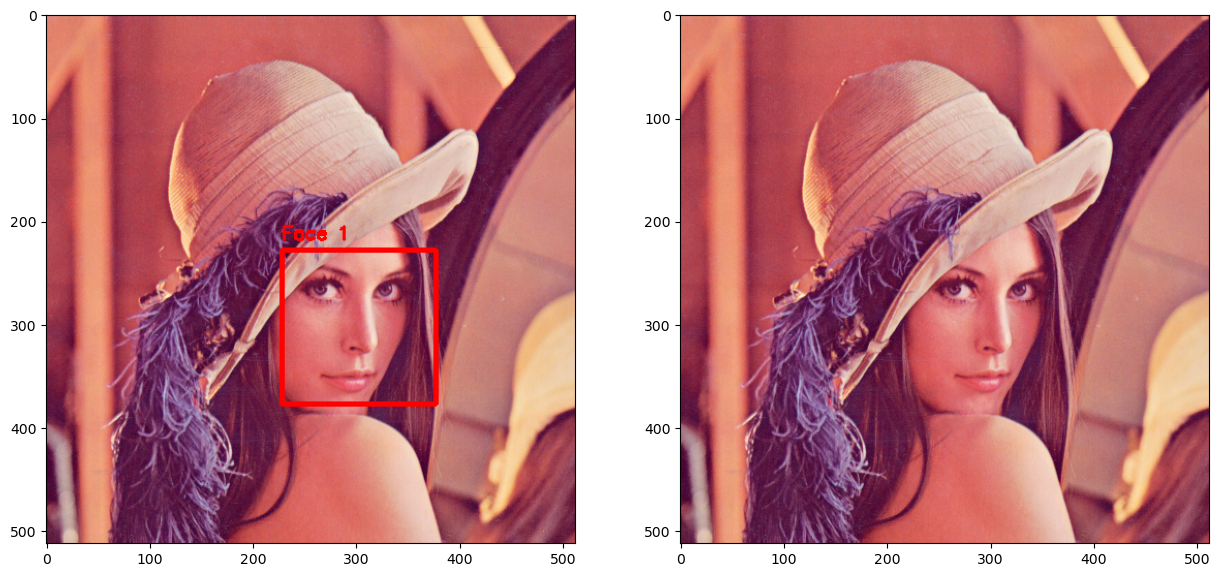

In [5]:
processed_img = img.copy()

for i, face in enumerate(faces):
    x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
    
    color = [255, 0, 0]

    cv2.rectangle(processed_img, (x1, y1), (x2, y2), color, 3)
    
    cv2.putText(processed_img, f"Face {i+1}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.subplot(121), plt.imshow(processed_img)
plt.subplot(122), plt.imshow(img)

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Faces: 2


(<Axes: >, <matplotlib.image.AxesImage at 0x2ae990d4590>)

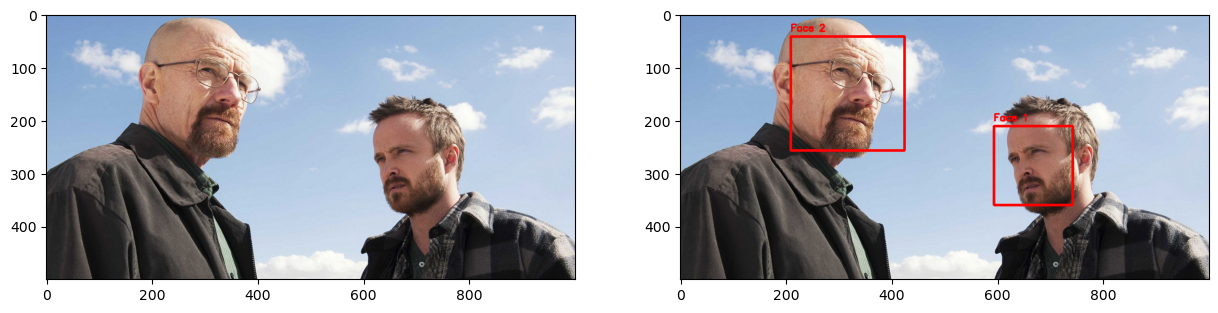

In [10]:
def detectFace(src_img):
    result_img = src_img.copy()
    
    faces = detector(result_img)

    print(f"Faces: {len(faces)}")

    for i, face in enumerate(faces):
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
    
        color = [255, 0, 0]
    
        cv2.rectangle(result_img, (x1, y1), (x2, y2), color, 3)
    
        cv2.putText(result_img, f"Face {i+1}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return result_img

def getImage(path: str):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

test_src_img = getImage("test1.png")
test_detected_img = detectFace(test_src_img)
plt.subplot(121), plt.imshow(test_src_img)
plt.subplot(122), plt.imshow(test_detected_img) 
